In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from lpips import LPIPS
from pytorch_msssim import SSIM

In [2]:
class TrainImageDataset(Dataset):
    def __init__(self, image_dir) -> None:
        self.image_dir = Path(image_dir)
        self.GT_PATH = self.image_dir / 'GT'  # Assuming GT images are in a subdirectory named 'GT'
        self.NoisyLR_PATH = self.image_dir / 'NoisyLR'  # Assuming NoisyLR images are in a subdirectory named 'NoisyLR'
        self.GT_image_paths = list(self.GT_PATH.glob('*.npy'))  # Assuming images are in .npy format
        self.NoisyLR_image_paths = list(self.NoisyLR_PATH.glob('*.npy'))  # Assuming images are in .npy format
        assert len(self.GT_image_paths) == len(self.NoisyLR_image_paths)

    def __len__(self) -> int:
        return len(self.GT_image_paths)

    def __getitem__(self, idx) -> tuple[np.ndarray, np.ndarray]:
        GT_image = np.load(self.GT_image_paths[idx])  # Load the GT image
        return zoom(GT_image, zoom=0.5, order=3), GT_image  # Return both images

    def refresh(self) -> None:
        self.GT_image_paths = list(self.GT_PATH.glob('*.npy'))
        self.NoisyLR_image_paths = list(self.NoisyLR_PATH.glob('*.npy'))
        assert len(self.GT_image_paths) == len(self.NoisyLR_image_paths)

In [3]:
orginal_train_dataset = TrainImageDataset(image_dir="../data/train/train")
augmented_train_dataset = TrainImageDataset(image_dir="../data/train/augmented_new_noise")
# augmented_test_dataset = TrainImageDataset(image_dir="../data/train/augmented_direct")

dataset = torch.utils.data.ConcatDataset([orginal_train_dataset, augmented_train_dataset])
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [int(len(dataset) * 0.8), len(dataset) - int(len(dataset) * 0.8)])
print("Total dataset size: ", len(dataset))
print("Train dataset size: ", len(train_dataset))
print("Test dataset size: ", len(test_dataset))

# shapes = [(a.shape, b.shape) for a, b in dataset]
# print(set([shape[0] for shape in shapes]), set([shape[1] for shape in shapes]))

Total dataset size:  3200
Train dataset size:  2560
Test dataset size:  640


In [4]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [5]:
class AntiAliasBlock(nn.Module): 
    def __init__(self, channels: int, kernel_size: int = 5, identity_weight: float = 0.9):
        super().__init__()
        assert kernel_size % 2 == 1, "kernel_size must be odd"
        self.kernel_size = kernel_size
        self.channels = channels
 
        self.conv = nn.Conv2d(
            channels, channels, kernel_size,
            padding=kernel_size // 2, groups=channels, bias=False
        )
 
        # Near-identity kernel: mostly a delta at the center, blended
        # with a small amount of uniform averaging.
        with torch.no_grad():
            k = kernel_size
            center = k // 2
            identity_kernel = torch.zeros(k, k)
            identity_kernel[center, center] = 1.0
 
            avg_kernel = torch.ones(k, k) / (k * k)
 
            blended = identity_weight * identity_kernel + (1 - identity_weight) * avg_kernel
            blended = blended / blended.sum()  # preserve DC gain = 1.0
 
            weight = blended.view(1, 1, k, k).repeat(channels, 1, 1, 1)
            self.conv.weight.copy_(weight)
 
    def forward(self, x):
        return self.conv(x)
 
 
class ESPCN(nn.Module):
    def __init__(self, scale_factor, num_channels=1,
                 aa_kernel_size: int = 5, aa_identity_weight: float = 0.9):
        super(ESPCN, self).__init__()
 
        # Feature extraction
        self.conv1 = nn.Conv2d(num_channels, 64, kernel_size=5, padding=2)
        self.tanh1 = nn.Tanh()
 
        # Non-linear mapping
        self.conv2 = nn.Conv2d(64, 32, kernel_size=3, padding=1)
        self.tanh2 = nn.Tanh()
 
        # Sub-pixel convolution layer
        self.conv3 = nn.Conv2d(32, num_channels * (scale_factor ** 2), kernel_size=3, padding=1)
        self.pixel_shuffle = nn.PixelShuffle(scale_factor)
 
        # Anti-aliasing block, applied after the sub-pixel shuffle
        self.anti_alias = AntiAliasBlock(
            channels=num_channels,
            kernel_size=aa_kernel_size,
            identity_weight=aa_identity_weight,
        )
 
    def forward(self, x):
        x = self.tanh1(self.conv1(x))
        x = self.tanh2(self.conv2(x))
        x = self.pixel_shuffle(self.conv3(x))
        x = self.anti_alias(x)
        return x

In [6]:
def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train()
    loss_histories = [[], [], []]
    for epoch in range(num_epochs):
        running_losses = [0.0, 0.0, 0.0]
        for inputs, targets in train_loader:
            inputs, targets = inputs.float().to(DEVICE), targets.float().to(DEVICE)  # Ensure the data is in float format
            optimizer.zero_grad()
            outputs = model(inputs)
            ch_loss, ffl_loss, sobel_lpips_loss = criterion(outputs, targets)
            loss = ch_loss + ffl_loss + sobel_lpips_loss
            loss.backward()
            optimizer.step()
            running_losses[0] += ch_loss.item()
            running_losses[1] += ffl_loss.item()
            running_losses[2] += sobel_lpips_loss.item()

        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {sum(running_losses) / len(train_loader):.4f}")
        print(f"Charbonnier Loss: {running_losses[0] / len(train_loader)}, FFL: {running_losses[1] / len(train_loader)}, SEGLPIPS: {running_losses[2] / len(train_loader)}")
        loss_histories[0].append(running_losses[0] / len(train_loader))
        loss_histories[1].append(running_losses[1] / len(train_loader))
        loss_histories[2].append(running_losses[2] / len(train_loader))

    return loss_histories

In [7]:
from focal_frequency_loss import FocalFrequencyLoss

class SobelEdgeGate(nn.Module):
    def __init__(self):
        super().__init__()
        # Sobel kernels for X and Y gradients
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32)
        
        # Register as non-trainable buffers
        self.register_buffer('weight_x', sobel_x.view(1, 1, 3, 3))
        self.register_buffer('weight_y', sobel_y.view(1, 1, 3, 3))

    def forward(self, x):
        # Convert RGB to Grayscale for edge extraction if needed
        if x.size(1) == 3:
            gray = 0.2989 * x[:, 0:1] + 0.5870 * x[:, 1:2] + 0.1140 * x[:, 2:3]
        else:
            gray = x

        edge_x = F.conv2d(gray, self.weight_x, padding=1)
        edge_y = F.conv2d(gray, self.weight_y, padding=1)

        # Magnitude of gradients
        magnitude = torch.sqrt(edge_x**2 + edge_y**2 + 1e-6)

        # Normalize between 0 and 1 per image/batch
        mag_max = magnitude.amax(dim=(2, 3), keepdim=True)
        gate = magnitude / (mag_max + 1e-6)
        return gate

class SobelGatedLPIPS(nn.Module):
    def __init__(self, net='vgg'):
        super().__init__()
        self.lpips = LPIPS(net=net, eval_mode=True)
        self.edge_gate = SobelEdgeGate()

    def forward(self, pred, target):
        # Standard LPIPS computes feature-space distance
        base_lpips = self.lpips(pred, target, normalize=True)
        
        # Compute edge mask based on target image structure
        gate = self.edge_gate(target)
        
        # Resize gate if necessary to match feature maps, or apply directly 
        # as a spatial weighting on the input space or final reduction
        gated_loss = (base_lpips * gate.mean(dim=(1,2,3), keepdim=True)).mean()
        return gated_loss

class CustomLoss(nn.Module):
    def __init__(self, epsilon=1e-6):
        """Charbonnier + Focal Freq + Sobel edge gated LPIPS"""
        super(CustomLoss, self).__init__()
        self.epsilon = epsilon
        self.ffl = FocalFrequencyLoss(loss_weight=1.0, alpha=1.0).to(DEVICE)
        self.sobel_lpips = SobelGatedLPIPS().to(DEVICE)

    def forward(self, prediction, target):
        diff = prediction - target
        ch_loss = torch.mean(torch.sqrt(diff * diff + self.epsilon * self.epsilon)).to(DEVICE)
        ffl_loss = self.ffl(target, prediction)
        sobel_lpips_loss = self.sobel_lpips(prediction, target)
        return ch_loss, 0.3 * ffl_loss, sobel_lpips_loss

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/vivaan/workingfolder/college/epoch/kla_hackathon/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vivaan/workingfolder/college/epoch/kla_hackathon/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/vivaan/workingfolder/college/epoch/kla_hackathon/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth
Epoch [1/10], Loss: 0.0714
Charbonnier Loss: 0.04123051946080523, FFL: 0.0007240150088165364, SEGLPIPS: 0.029479473120591137
Epoch [2/10], Loss: 0.0508
Charbonnier Loss: 0.02787007429287769, FFL: 0.00013021316239871794, SEGLPIPS: 0.022803899741848
Epoch [3/10], Loss: 0.0484
Charbonnier Loss: 0.026848534337477758, FFL: 0.0001229990923448554, SEGLPIPS: 0.02141269161584205
Epoch [4/10], Loss: 0.0479
Charbonnier Loss: 0.027076241788745393, FFL: 0.00012541777953956057, SEGLPIPS: 0.020705758361145854
Epoch [5/10], Loss: 0.0473
Charbonnier Loss: 0.026813330530421807, FFL: 0.00012924335655810636, SEGLPIPS: 0.02031618742039427
Epoch [6/10], Loss: 0.0467
Charbonnier Loss: 0.026461348986049415, FFL: 0.0001281541046225243, SEGLPIPS: 0.020155101933778497
Epoch [7/10], Loss: 0.0466
Charbonnier Loss: 0.026430684798106084, FFL: 0.00012654358578743086, SEGLPIPS: 0.020

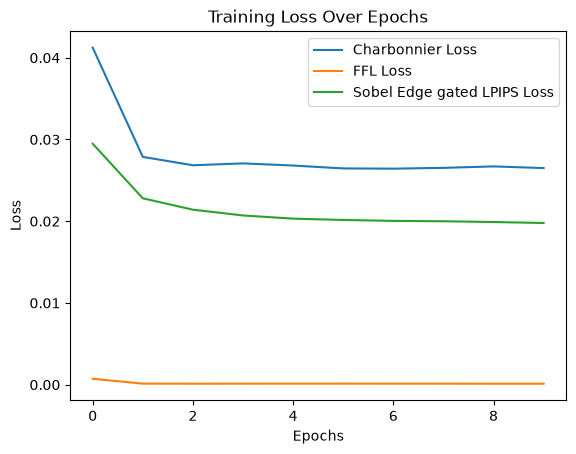

In [8]:
def collate_to_list(batch):
    # Separate data and labels into lists
    data = torch.tensor(np.array([item[0] for item in batch])).unsqueeze(1)  # Add channel dimension for grayscale images
    labels = torch.tensor(np.array([item[1] for item in batch])).unsqueeze(1)  # Add channel dimension for grayscale images
    return data, labels

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_to_list, num_workers=4)  # Adjust batch size as needed
model = ESPCN(scale_factor=2, num_channels=1).to(DEVICE)
with torch.no_grad(): # ICNR init
    conv = model.conv3
    out_channels, in_channels, kh, kw = conv.weight.shape
    r2 = 4
    sub_kernel = torch.empty(out_channels//r2, in_channels, kh, kw,  device=DEVICE)
    nn.init.kaiming_normal_(sub_kernel, nonlinearity="relu")

    conv.weight.copy_(sub_kernel.repeat_interleave(r2, dim=0))
    if conv.bias is not None:
        conv.bias.zero_()

train_criterion = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # Adjust learning rate as needed
train_loss_histories = train_model(model, train_loader, train_criterion, optimizer, num_epochs=10)
# model.load_state_dict(torch.load("../models/restormer_model.pth", map_location=DEVICE))  # Load the model state dict

plt.plot(train_loss_histories[0], label="Charbonnier Loss")
plt.plot(train_loss_histories[1], label="FFL Loss")
plt.plot(train_loss_histories[2], label="Sobel Edge gated LPIPS Loss")
plt.legend()
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

In [9]:
torch.save(model.state_dict(), "../models/espcn_model_loss2.pth")  # Save the model state dict

In [10]:
# measure test loss
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=collate_to_list, num_workers=4)
model.eval()
test_loss = 0.0
#graph test loss over batches       
for batch_idx, (data, target) in enumerate(test_loader):
    data, target = data.to(DEVICE), target.to(DEVICE)
    output = model(data)
    loss = sum(train_criterion(output, target))
    test_loss += loss.item()
test_loss /= len(test_loader)
print(f"Test Loss: {test_loss}")


Test Loss: 0.0457716440432705


Upscaling time for one image: 0.0003 seconds


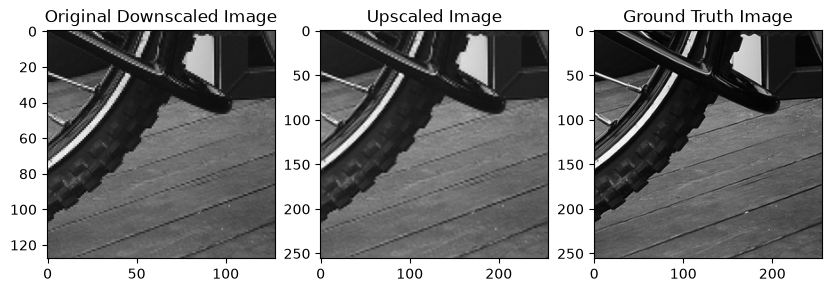

Charbonnier Loss 0.026024922728538513
FFL Loss 0.00033841071941424165
Sobel Edge gated LPIPS Loss 0.018212201073765755
Time taken for upscaling: 0.0003364086151123047 seconds


In [19]:
# view a few test images and their predictions
import random
import time

i = random.randint(0, len(test_dataset) - 1)
sample_image = torch.from_numpy(test_dataset[i][0]).unsqueeze(0).unsqueeze(0).to(DEVICE).float()  

time_start = time.time()
restored_image = model(sample_image)
time_end = time.time()
print(f"Upscaling time for one image: {time_end - time_start:.4f} seconds")

fig, axs = plt.subplots(1, 3, figsize=(10, 5))
# Display the original downscaled image
axs[0].imshow(sample_image.squeeze().cpu().numpy(), cmap='gray')
axs[0].set_title("Original Downscaled Image")
# Display the restored image
axs[1].imshow(restored_image.squeeze().detach().cpu().numpy(), cmap='gray')
axs[1].set_title("Upscaled Image")
# Display the ground truth image
axs[2].imshow(test_dataset[i][1], cmap='gray')
axs[2].set_title("Ground Truth Image")
plt.show()

losses = train_criterion(restored_image, torch.tensor(test_dataset[i][1], device=DEVICE).unsqueeze(0).unsqueeze(0))
print("Charbonnier Loss", losses[0].item())
print("FFL Loss", losses[1].item() * 3.333)
print("Sobel Edge gated LPIPS Loss", losses[2].item())
print("Time taken for upscaling:", time_end - time_start, "seconds")